# Decision Trees and ensembles — Don't Get Kicked!

**Goal.** Predict whether a car bought at an auto auction is a *lemon*
(`IsBadBuy = 1`) with tree based models, and go through the whole ladder:

1. a **CART written from scratch** (`Node`, `DecisionTreeClassifier`,
   `DecisionTreeRegressor`, plus an extra-randomised splitter),
2. **bagging** — our own `RandomForestClassifier` and `ExtraTreesClassifier`,
3. **boosting** — our own `GradientBoostingClassifier` on the binary
   cross-entropy gradient,
4. the industrial implementations **LightGBM / XGBoost / CatBoost**.

Everything is evaluated with the Gini coefficient $\mathrm{Gini} = 2\,\mathrm{AUC} - 1$
on a strict **time based** train / validation / test split; the test fold is only
touched in Step 8.

**Where the code lives.** The model classes are implemented in the `src/` package of
this repository (`src/tree.py`, `src/ensemble.py`, `src/gbdt.py`, `src/data.py`) and
imported here, so the notebook stays readable; every class is shown in action below.

**Data note.** `data/training.csv` is the *DontGetKicked* competition data obtained via
OpenML ("kick" dataset), 72 983 rows x 33 columns. Coming from OpenML, `PurchDate` is a
**unix epoch in seconds** rather than a date string and `IsBadBuy` is already an integer
0/1 column; `src.data.load_raw` converts the date and sorts the frame chronologically.

In [1]:
import inspect
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import (
    RANDOM_STATE,
    TARGET,
    FrequencyEncoder,
    OrdinalEncoder,
    build_datasets,
    gini,
    load_raw,
    time_split,
)
from src.tree import DecisionTreeClassifier, DecisionTreeRegressor, Node
from src.ensemble import ExtraTreesClassifier, RandomForestClassifier
from src.gbdt import GradientBoostingClassifier, sigmoid

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(RANDOM_STATE)

# Minimal chart style: recessive axes/grid, colors assigned in fixed order.
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "font.size": 10, "figure.dpi": 100,
})

pd.set_option("display.max_columns", 40)

NB_START = time.perf_counter()
VALID_GINI = {}          # model -> validation Gini, filled in as we go


def timed(build):
    """Run ``build()`` and return ``(result, elapsed seconds)``."""
    start = time.perf_counter()
    result = build()
    return result, time.perf_counter() - start


print("RANDOM_STATE =", RANDOM_STATE, "| target column:", TARGET)

RANDOM_STATE = 42 | target column: IsBadBuy


## Step 1. Data, EDA and the time based train / validation / test split

*README task 1.* The split must satisfy `train.PurchDate < valid.PurchDate <
test.PurchDate` with roughly a third of the data in each fold, and the categorical
encoders must be fitted on the training fold only.

`src.data.time_split` cuts on the **unique purchase dates** — the first 33 % of the 517
distinct days to train, the next 33 % to validation, the rest to test — and not on the
row count, so that no calendar day is ever spread over two folds and the strict ordering
above holds by construction. Because the auction volume grows over the period, near-equal
shares of the *days* give noticeably unequal shares of the *rows* —
**31.3 / 32.7 / 36.0 %** below instead of an exact 33 / 33 / 33. That is the intended
reading of "the last 33 % of the data": a clean time boundary is worth more here than an
exact row count, and the test fold being the largest only makes the final estimate more
stable.

In [2]:
df = load_raw("data/training.csv")
print("shape:", df.shape)
print("PurchDate:", df["PurchDate"].min().date(), "->", df["PurchDate"].max().date(),
      f"({df['PurchDate'].nunique()} distinct dates)")
print(f"\ntarget rate (share of lemons): {df[TARGET].mean():.4f}")
print(df[TARGET].value_counts().rename("rows").to_string())
print("\ndtypes:")
print(df.dtypes.value_counts().to_string())
df.head(3)

shape: (72983, 33)
PurchDate: 2009-01-05 -> 2010-12-30 (517 distinct dates)

target rate (share of lemons): 0.1230
IsBadBuy
0    64007
1     8976

dtypes:
str              14
float64          10
int64             8
datetime64[s]     1


,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,0,2009-01-05,MANHEIM,2006,3,CHEVROLET,COBALT 2.2L I4 MPI,LT,4D SEDAN LT,SILVER,AUTO,1.0,Alloy,80079,AMERICAN,COMPACT,GM,6110.0,6989.0,7099.0,8048.0,6113.0,7143.0,7102.0,8214.0,NaN,NaN,16044,27542,NC,5500.0,0,853
1,0,2009-01-05,MANHEIM,2007,2,CHEVROLET,UPLANDER FWD V6 3.9L,LS,PASSENGER EXT 3.5L,WHITE,AUTO,1.0,Alloy,79769,AMERICAN,VAN,GM,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,16044,27542,NC,6000.0,0,2091
2,0,2009-01-05,MANHEIM,2005,4,CHEVROLET,VENTURE FWD V6 3.4L,LS,PASSENGER EXT 3.4L LS,MAROON,AUTO,1.0,Alloy,80407,AMERICAN,VAN,GM,4230.0,5192.0,5068.0,6107.0,4034.0,5047.0,4857.0,5951.0,NaN,NaN,17675,27542,NC,4900.0,0,5092


In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("columns with missing values:")
print(missing.to_frame("n_missing").assign(share=lambda t: (t.n_missing / len(df)).round(4))
      .to_string())

columns with missing values:
                                   n_missing   share
AUCGUART                               69564  0.9532
PRIMEUNIT                              69564  0.9532
WheelType                               3174  0.0435
WheelTypeID                             3169  0.0434
Trim                                    2360  0.0323
MMRCurrentAuctionCleanPrice              315  0.0043
MMRCurrentRetailAveragePrice             315  0.0043
MMRCurrentAuctionAveragePrice            315  0.0043
MMRCurrentRetailCleanPrice               315  0.0043
VehBCost                                  68  0.0009
MMRAcquisitionAuctionAveragePrice         18  0.0002
MMRAcquisitionAuctionCleanPrice           18  0.0002
MMRAcquisitonRetailCleanPrice             18  0.0002
MMRAcquisitionRetailAveragePrice          18  0.0002
Transmission                               9  0.0001
SubModel                                   8  0.0001
Color                                      8  0.0001
TopThreeAmericanN

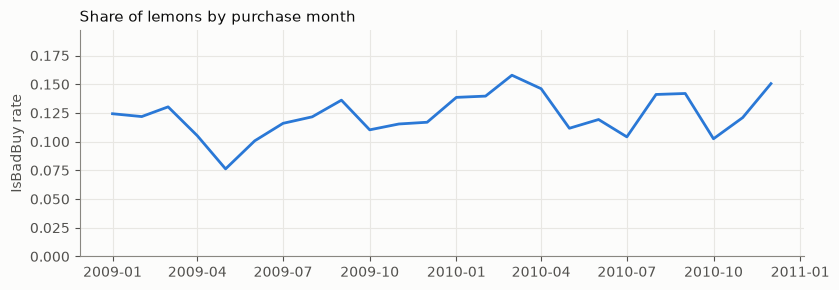

In [4]:
monthly = df.set_index("PurchDate")[TARGET].resample("MS").mean()

fig, ax = plt.subplots(figsize=(8.5, 3))
ax.plot(monthly.index, monthly.values, color=C_BLUE, lw=2)
ax.set_title("Share of lemons by purchase month", loc="left", fontsize=11)
ax.set_ylabel("IsBadBuy rate")
ax.set_ylim(0, monthly.max() * 1.25)
plt.tight_layout()
plt.show()

**Observations.** About 12.3 % of the cars are lemons, so the classes are imbalanced
(roughly 1 : 7) — accuracy is meaningless here and a ranking metric (Gini / AUC) is the
right choice. Several columns have missing values: `PRIMEUNIT` / `AUCGUART` are almost
entirely missing, the eight MMR price columns and `Trim` / `WheelType` partially. The
lemon rate also **drifts over time** (it climbs through 2009 and settles lower in 2010),
which is exactly why a time based split is required: a random split would leak future
market conditions into training and produce an over-optimistic estimate.

In [5]:
train, valid, test = time_split(df)

# hard guarantee of the temporal ordering required by the task
assert train["PurchDate"].max() < valid["PurchDate"].min()
assert valid["PurchDate"].max() < test["PurchDate"].min()
assert len(train) + len(valid) + len(test) == len(df)
print("ordering train < valid < test -> asserted\n")

fold_table = pd.DataFrame([
    {"fold": name, "rows": len(part), "share": len(part) / len(df),
     "first date": part["PurchDate"].min().date(),
     "last date": part["PurchDate"].max().date(),
     "lemon rate": part[TARGET].mean()}
    for name, part in [("train", train), ("valid", valid), ("test", test)]
]).set_index("fold")
fold_table.round(4)

ordering train < valid < test -> asserted



,rows,share,first date,last date,lemon rate
fold,,,,,
train,22857,0.3132,2009-01-05,2009-08-31,0.1128
valid,23826,0.3265,2009-09-01,2010-04-27,0.1326
test,26300,0.3604,2010-04-28,2010-12-30,0.1231


### Encoding the categorical variables without leakage

The task suggests `LabelEncoder` / `OneHotEncoder` but warns about **categories that
appear only in validation / test**. With a *time* split this is not a theoretical worry:
new car models start selling later, so a large share of the validation rows carries a
`Model` value the training period never saw. `LabelEncoder` raises on those values, and
one-hot encoding a column with ~800 levels explodes the dimensionality (and produces
mostly-empty columns that a tree cannot use).

In [6]:
unseen = pd.DataFrame([
    {"column": c,
     "levels in train": train[c].nunique(),
     "unseen in valid": (~valid[c].dropna().isin(train[c].dropna().unique())).mean(),
     "unseen in test": (~test[c].dropna().isin(train[c].dropna().unique())).mean()}
    for c in ["Model", "SubModel", "Trim", "Make", "Color", "VNZIP1", "BYRNO"]
]).set_index("column")
unseen.round(4)

,levels in train,unseen in valid,unseen in test
column,,,
Model,790,0.1667,0.2319
SubModel,647,0.0116,0.0151
Trim,121,0.0008,0.0011
Make,31,0.0003,0.0011
Color,16,0.0000,0.0000
VNZIP1,111,0.0296,0.0785
BYRNO,35,0.0492,0.1725


In [7]:
# src.data.build_datasets does the whole pipeline: time split -> encoder fitted on
# TRAIN only -> train medians for the numeric NaNs -> *_nan missing indicators.
data, seconds = timed(build_datasets)
Xtr, Xva, Xte = data["Xtr"], data["Xva"], data["Xte"]
ytr, yva, yte = data["ytr"], data["yva"], data["yte"]
feature_names = data["feature_names"]
cat_cols, num_cols = data["cat_cols"], data["num_cols"]

print(f"built in {seconds:.1f}s")
print("design matrices:", Xtr.shape, Xva.shape, Xte.shape, "| any NaN:",
      bool(np.isnan(Xtr).any() or np.isnan(Xva).any() or np.isnan(Xte).any()))
print(f"{len(feature_names)} features = {len(cat_cols)} categorical "
      f"+ {len(num_cols)} numeric + "
      f"{len(feature_names) - len(cat_cols) - len(num_cols)} missing-indicator flags")
print("\ncategorical:", cat_cols)
print("\nnumeric:", num_cols)

built in 0.4s
design matrices: (22857, 40) (23826, 40) (26300, 40) | any NaN: False
40 features = 17 categorical + 14 numeric + 9 missing-indicator flags

categorical: ['Auction', 'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID', 'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'PRIMEUNIT', 'AUCGUART', 'BYRNO', 'VNZIP1', 'VNST']

numeric: ['VehYear', 'VehicleAge', 'VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'IsOnlineSale', 'WarrantyCost']


In [8]:
# The encoder is an OrdinalEncoder fitted on train; unseen categories -> -1.
encoder = data["encoder"]
print(type(encoder).__name__, "| unknown_value =", encoder.unknown_value)
print("codes learned for 'Make':", dict(list(encoder.mapping_["Make"].items())[:5]), "...")

model_col = feature_names.index("Model")
for name, matrix in [("train", Xtr), ("valid", Xva), ("test", Xte)]:
    share = (matrix[:, model_col] == -1).mean()
    print(f"{name:5s}: {share:6.2%} of the rows have Model == -1 (unseen in train)")

OrdinalEncoder | unknown_value = -1.0
codes learned for 'Make': {'ACURA': 0, 'BUICK': 1, 'CADILLAC': 2, 'CHEVROLET': 3, 'CHRYSLER': 4} ...
train:  0.00% of the rows have Model == -1 (unseen in train)
valid: 16.67% of the rows have Model == -1 (unseen in train)
test : 23.19% of the rows have Model == -1 (unseen in train)


In [9]:
# The alternative the task links to: count / frequency encoding, where an unseen
# category becomes 0.0 ("rarer than anything we know") instead of a separate code.
freq_data, seconds = timed(lambda: build_datasets(encoding="frequency"))
print(f"frequency-encoded datasets built in {seconds:.1f}s")

rows = []
for label, dset in [("ordinal (unseen -> -1)", data), ("frequency (unseen -> 0.0)", freq_data)]:
    tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=50,
                                  random_state=RANDOM_STATE).fit(dset["Xtr"], dset["ytr"])
    rows.append({"encoding": label,
                 "train Gini": gini(dset["ytr"], tree.predict_proba(dset["Xtr"])),
                 "valid Gini": gini(dset["yva"], tree.predict_proba(dset["Xva"]))})
pd.DataFrame(rows).set_index("encoding").round(4)

frequency-encoded datasets built in 0.4s


,train Gini,valid Gini
encoding,,
ordinal (unseen -> -1),0.5322,0.4558
frequency (unseen -> 0.0),0.5441,0.4299


**Which encoding, and why is it leakage free?**

* **Both encoders are fitted on the training fold only** and then *applied* to validation
  and test — never re-fitted. The same holds for the medians used to impute the numeric
  NaNs and for the decision of which `*_nan` indicator columns to keep. Nothing that a
  model sees at training time depends on a future row.
* We keep **ordinal encoding with `unseen -> -1`** as the main pipeline. For a tree this
  is not the "false ordering" problem it would be for a linear model: a tree only ever
  compares a code with a threshold, and it can isolate any group of codes by stacking
  splits. The reserved value `-1` sits below every real code, so "category not seen in
  the training period" is a branch the tree can learn explicitly — which matters, because
  ~17 % of the validation rows and ~23 % of the test rows have an unseen `Model`.
* **Frequency (count) encoding** — the `category_encoders.CountEncoder` approach the task
  links to — is the natural alternative and is implemented in `src/data.py` as well: it
  maps every category to its training-set share and unseen values to `0.0`, so rare and
  unseen levels end up next to each other, which is often exactly the right prior. On
  this data it is measurably *worse* for a single tree (validation Gini 0.4299 against
  0.4558, table above) precisely because that conflation throws information away: it
  cannot distinguish "a model we have never sold" from "a model we sold twice", and it
  makes two unrelated categories of equal frequency indistinguishable. We therefore keep
  ordinal encoding, which leaves "unseen" separable from "rare but known".
* One-hot encoding is deliberately avoided: with `Model` (790 train levels), `VNZIP1` and
  `BYRNO` it would create thousands of sparse columns, which is the worst possible input
  shape for an axis-parallel greedy tree.

## Step 2. The tree written from scratch: `Node`, `DecisionTreeClassifier`, `DecisionTreeRegressor`

*README task 2.* The implementation lives in **`src/tree.py`**:

* **`Node`** — holds the samples that reached it (`indices` / `targets`), its
  `n_samples`, its `impurity`, its prediction `value`, the split it performs
  (`feature`, `threshold`) and the pointers `left` / `right`. It also exposes the two
  criteria as static methods: `Node.gini_impurity` and `Node.mse_impurity`.
* **`DecisionTreeClassifier`** — CART with the **Gini impurity** criterion, parameters
  `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `max_bins`,
  `splitter`, `random_state`; methods `fit`, `predict_proba`, `predict`.
* **`DecisionTreeRegressor`** — the same machinery with the **MSE** criterion (variance
  reduction is the same ordering as the standard-deviation reduction the task mentions).
  It is the base learner of the GBDT in Step 6.

**Impurity and the split score.** For a node with class shares $p_k$,

$$G = 1 - \sum_k p_k^2, \qquad
\Delta G = G_{\text{parent}} - \frac{n_L}{n}G_L - \frac{n_R}{n}G_R,$$

and the split with the largest $\Delta G$ wins (for the regressor, $G$ is replaced by the
variance).

**How the best split is found (`_find_split`).** A naive scan costs
$O(n\_features \times n\_rows)$ *sorted* passes per node. Instead every column is
**pre-binned into at most `max_bins = 32` quantile bins once** (class `Binning`), so a
threshold is just a bin index. For a node the `(row, feature)` bin codes are flattened
into one integer array, a single `np.bincount` produces the per-`(feature, bin)` class
histogram, and a `cumsum` along the bin axis evaluates **every threshold of every
feature simultaneously**. That is why a fit over 22 857 x 40 takes ~0.05 s in pure numpy.

**Extra randomised splitter.** With `splitter="random"` the candidate set is reduced to
**one uniformly drawn threshold per candidate feature** and the best of those draws is
taken (Geurts et al., *Extremely randomized trees*). It is the base learner of
`ExtraTreesClassifier` in Step 9.

In [10]:
print("classes implemented in src/tree.py:",
      [n for n in ("Node", "Binning", "DecisionTreeClassifier", "DecisionTreeRegressor")])
print(inspect.getsource(Node.gini_impurity))
print(inspect.getsource(Node.mse_impurity))

classes implemented in src/tree.py: ['Node', 'Binning', 'DecisionTreeClassifier', 'DecisionTreeRegressor']
    @staticmethod
    def gini_impurity(y: np.ndarray) -> float:
        """Gini impurity ``1 - sum(p_k^2)`` of a label vector."""
        y = np.asarray(y)
        if y.size == 0:
            return 0.0
        counts = np.bincount(y.astype(np.int64))
        p = counts / y.size
        return float(1.0 - np.sum(p * p))

    @staticmethod
    def mse_impurity(y: np.ndarray) -> float:
        """Variance (mean squared error around the mean) of a target vector."""
        y = np.asarray(y, dtype=np.float64)
        if y.size == 0:
            return 0.0
        return float(np.mean((y - y.mean()) ** 2))



In [11]:
# The blueprint from the README, verbatim.
model = DecisionTreeClassifier(max_depth=7)
model.fit(Xtr, ytr)
proba = model.predict_proba(Xva)

print("predict_proba ->", proba.shape, "| rows sum to 1:", np.allclose(proba.sum(1), 1))
print("predict       ->", model.predict(Xva)[:10], "| classes_:", model.classes_)
assert np.array_equal(model.predict(Xva), model.classes_[np.argmax(proba, axis=1)])
print("\nparameters:", model.get_params())
print(f"depth {model.get_depth()} | {model.get_n_leaves()} leaves | {model.n_nodes_} nodes")

predict_proba -> (23826, 2) | rows sum to 1: True
predict       -> [0 0 0 0 0 0 0 0 0 0] | classes_: [0 1]

parameters: {'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_bins': 32, 'splitter': 'best', 'random_state': None, 'min_impurity_decrease': 0.0}
depth 7 | 100 leaves | 199 nodes


In [12]:
# A stand-alone tree keeps the samples inside every Node (store_indices=True).
tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=50,
                              random_state=RANDOM_STATE, store_indices=True)
tree.fit(Xtr, ytr)

root = tree.root_
print("root  :", root)
print("       rule:", root.split_rule(), "->", feature_names[root.feature],
      f"<= {root.threshold:g}")
print("       value (class distribution):", root.value.round(4))
print("       indices:", root.indices.shape, "| targets:", root.targets.shape)
print("left  :", root.left)
print("right :", root.right)

# the Node criterion recomputed by hand from the stored targets
manual = Node.gini_impurity(root.targets)
n_l, n_r = root.left.n_samples, root.right.n_samples
decrease = root.impurity - (n_l * root.left.impurity + n_r * root.right.impurity) / root.n_samples
print(f"\nNode.gini_impurity(root.targets) = {manual:.6f} == root.impurity "
      f"{root.impurity:.6f} -> {np.isclose(manual, root.impurity)}")
print(f"weighted Gini decrease of the root split = {decrease:.6f}")

root  : <Node depth=0 n=22857 impurity=0.2002 rule=x[7] <= -1>
       rule: x[7] <= -1 -> WheelTypeID <= -1
       value (class distribution): [0.8872 0.1128]
       indices: (22857,) | targets: (22857,)
left  : <Node depth=1 n=861 impurity=0.4169 rule=x[0] <= 0>
right : <Node depth=1 n=21996 impurity=0.1633 rule=x[17] <= 2003>

Node.gini_impurity(root.targets) = 0.200202 == root.impurity 0.200202 -> True
weighted Gini decrease of the root split = 0.027344


**Reading the root split.** The tree opens on `WheelTypeID <= -1`, i.e. on our
"category unseen / missing" code: the 861 cars whose wheel type is unknown have a Gini
impurity of 0.417 (roughly 30 % lemons) against 0.163 on the other side — by far the
strongest single question that can be asked about this data set. It is a good
illustration of why we kept a *reserved* code for missing/unseen categories instead of
imputing them away.

In [13]:
# splitter="random" -> extra randomised tree (one random threshold per feature)
rows = []
for label, params in [
    ("CART, splitter='best'",
     dict(max_depth=7, min_samples_leaf=50, random_state=RANDOM_STATE)),
    ("Extra randomised, splitter='random'",
     dict(max_depth=7, min_samples_leaf=50, splitter="random", random_state=RANDOM_STATE)),
]:
    fitted, seconds = timed(lambda p=params: DecisionTreeClassifier(**p).fit(Xtr, ytr))
    rows.append({"tree": label,
                 "train Gini": gini(ytr, fitted.predict_proba(Xtr)),
                 "valid Gini": gini(yva, fitted.predict_proba(Xva)),
                 "leaves": fitted.get_n_leaves(),
                 "fit, s": seconds})
    if label.startswith("Extra"):
        VALID_GINI["own ExtraRandomizedTree (depth 7)"] = rows[-1]["valid Gini"]
pd.DataFrame(rows).set_index("tree").round(4)

,train Gini,valid Gini,leaves,"fit, s"
tree,,,,
"CART, splitter='best'",0.5322,0.4558,66,0.0572
"Extra randomised, splitter='random'",0.5090,0.4423,65,0.0645


In [14]:
# DecisionTreeRegressor (MSE criterion) - the base learner of the GBDT in Step 6.
from sklearn.tree import DecisionTreeRegressor as SkDecisionTreeRegressor

target_index = feature_names.index("VehBCost")
numeric_index = [feature_names.index(c) for c in num_cols if c != "VehBCost"][:12]
Atr, btr = Xtr[:4000][:, numeric_index], Xtr[:4000, target_index]
Ava, bva = Xva[:4000][:, numeric_index], Xva[:4000, target_index]

reg_params = dict(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE)
own_reg = DecisionTreeRegressor(**reg_params).fit(Atr, btr)
sk_reg = SkDecisionTreeRegressor(**reg_params).fit(Atr, btr)

rmse = lambda y, p: float(np.sqrt(np.mean((y - p) ** 2)))
print("task: predict VehBCost from 12 numeric columns (4000 rows)")
print(f"  ours    RMSE = {rmse(bva, own_reg.predict(Ava)):8.2f} | "
      f"root variance = {own_reg.root_.impurity ** 0.5:8.2f} | leaves = {own_reg.get_n_leaves()}")
print(f"  sklearn RMSE = {rmse(bva, sk_reg.predict(Ava)):8.2f} | "
      f"leaves = {sk_reg.get_n_leaves()}")
print("\nNode.mse_impurity(root.targets) == root.impurity:",
      np.isclose(Node.mse_impurity(own_reg.root_.targets), own_reg.root_.impurity))

task: predict VehBCost from 12 numeric columns (4000 rows)
  ours    RMSE =  1113.44 | root variance =  1602.07 | leaves = 29
  sklearn RMSE =  1055.00 | leaves = 30

Node.mse_impurity(root.targets) == root.impurity: True


**What Step 2 shows.** `fit` / `predict_proba` / `predict` work exactly as the blueprint
requires; `max_depth` (and the other stopping rules) are constructor parameters; the
`Node` objects really hold their samples, their impurity and their children, and the
impurity recomputed by hand from `node.targets` matches what the fit stored. The
extra-randomised splitter costs ~0.014 Gini on validation compared with the exhaustive
scan — a *weaker* tree, which is precisely what makes it useful inside an ensemble
(Step 9). The regressor reaches an RMSE within ~6 % of sklearn's on the same task; the
difference comes from the 32-bin quantile grid, which only offers a subset of the exact
thresholds sklearn can pick.

## Step 3. Validation Gini of our tree (requirement: >= 0.10)

*README task 3.*

In [15]:
tree_train_gini = gini(ytr, tree.predict_proba(Xtr))
tree_valid_gini = gini(yva, tree.predict_proba(Xva))
VALID_GINI["own DecisionTree (depth 7)"] = tree_valid_gini

print(f"own DecisionTreeClassifier(max_depth=7, min_samples_leaf=50)")
print(f"  train Gini = {tree_train_gini:.4f}")
print(f"  valid Gini = {tree_valid_gini:.4f}")
assert tree_valid_gini >= 0.10, "README task 3 requires a validation Gini >= 0.10"
print(f"\nrequirement >= 0.10 -> passed ({tree_valid_gini:.4f})")

own DecisionTreeClassifier(max_depth=7, min_samples_leaf=50)
  train Gini = 0.5322
  valid Gini = 0.4558

requirement >= 0.10 -> passed (0.4558)


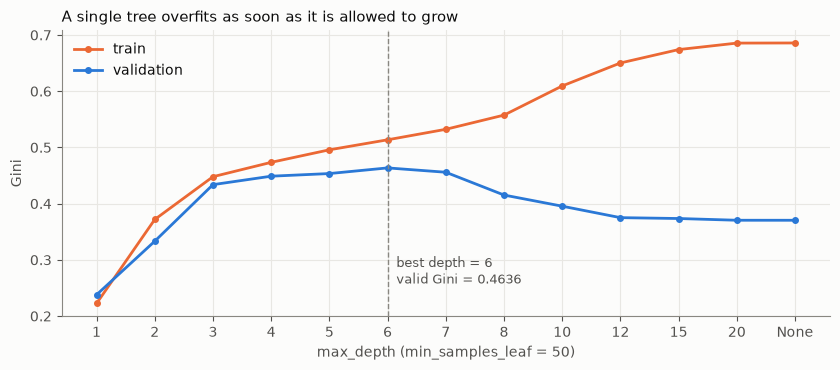

fully grown tree (max_depth=None, min_samples_leaf=1): train Gini = 1.0000, valid Gini = 0.1879, 2712 leaves, depth 35


,max_depth,train Gini,valid Gini,leaves
0,1,0.2224,0.2379,2
1,2,0.3718,0.3332,4
2,3,0.4479,0.4338,8
3,4,0.4735,0.4488,15
4,5,0.4957,0.4535,27
5,6,0.5136,0.4636,42
6,7,0.5322,0.4558,66
7,8,0.5575,0.4153,97
8,10,0.6094,0.3955,159
9,12,0.6502,0.3751,224


In [16]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
rows = []
for depth in depths:
    fitted = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=50,
                                    random_state=RANDOM_STATE).fit(Xtr, ytr)
    rows.append({"max_depth": depth if depth is not None else "None",
                 "train Gini": gini(ytr, fitted.predict_proba(Xtr)),
                 "valid Gini": gini(yva, fitted.predict_proba(Xva)),
                 "leaves": fitted.get_n_leaves()})
sweep = pd.DataFrame(rows)

# the fully grown tree: no depth limit AND no leaf-size limit
full = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1,
                              random_state=RANDOM_STATE).fit(Xtr, ytr)
full_train = gini(ytr, full.predict_proba(Xtr))
full_valid = gini(yva, full.predict_proba(Xva))

x = np.arange(len(sweep))
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(x, sweep["train Gini"], color=C_ORANGE, lw=2, marker="o", ms=4, label="train")
ax.plot(x, sweep["valid Gini"], color=C_BLUE, lw=2, marker="o", ms=4, label="validation")
best = int(sweep["valid Gini"].idxmax())
ax.axvline(best, color=MUTED, lw=1, ls="--")
ax.annotate(f"best depth = {sweep.loc[best, 'max_depth']}\nvalid Gini = "
            f"{sweep.loc[best, 'valid Gini']:.4f}",
            xy=(best + 0.15, sweep["valid Gini"].min() + 0.02), color=INK2, fontsize=9)
ax.set_xticks(x, sweep["max_depth"].astype(str))
ax.set_xlabel("max_depth (min_samples_leaf = 50)")
ax.set_ylabel("Gini")
ax.set_title("A single tree overfits as soon as it is allowed to grow", loc="left",
             fontsize=11)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"fully grown tree (max_depth=None, min_samples_leaf=1): "
      f"train Gini = {full_train:.4f}, valid Gini = {full_valid:.4f}, "
      f"{full.get_n_leaves()} leaves, depth {full.get_depth()}")
sweep.round(4)

**The requirement is met with a wide margin: 0.4558 >= 0.10.**

The sweep is the textbook picture of the CART weakness the introduction warns about.
Validation Gini rises steeply to a plateau at depth 5-7 (peak **0.4636 at depth 6**,
0.4558 at depth 7) and then *falls* while the training Gini keeps climbing — from depth 8
onwards the tree is fitting auction-specific noise of the training months. Removing every
brake at once (`max_depth=None, min_samples_leaf=1`) drives the training Gini to **1.0**
(each leaf holds a single row) and collapses validation to **0.1879**: memorisation, zero
generalisation.

**Depth 6 is the better point estimate.** With `splitter="best"` and `max_features=None`
our fit is fully deterministic — `random_state` changes nothing, every seed returns the
same 0.4558 at depth 7 — so the 0.008 gap is *not* run-to-run variance. The only noise
here is the **sampling noise of the validation fold** (23 826 rows, 12 % of them
positive): the same two trees scored on a different set of September-April auctions
would not necessarily rank the same way. A paired bootstrap of the validation rows
(2 000 resamples, run as a side check outside this notebook) puts the difference
depth 6 − depth 7 at **+0.0076 Gini, 95 % CI [−0.0001, +0.0155]** — not significant at
the 95 % level, although depth 6 does come out ahead in ~97 % of the resamples.

We nevertheless keep **`max_depth=7, min_samples_leaf=50`** as the reference tree: it is
the value the README blueprint prescribes and it sits inside the depth 5-7 plateau, so
the comparison against sklearn (Step 4) and against the ensembles (Steps 5, 6, 9) is run
at the blueprint's setting rather than at a value picked by looking at the validation
fold. Every conclusion in this notebook survives the swap: depth 6 would move the single
tree from 0.4558 to 0.4636 and leave it far below the forest (0.4847) and the boosted
models (0.4964-0.5015).

## Step 4. sklearn's `DecisionTreeClassifier` — is it better, and why?

*README task 4.* We compare at **matched settings** (same criterion, same `max_depth`,
same `min_samples_leaf`, same seed) across the depth range, so the comparison isolates
the implementation and not the hyperparameters.

In [17]:
from sklearn.tree import DecisionTreeClassifier as SkDecisionTreeClassifier

rows = []
for depth in [3, 5, 7, 10, None]:
    params = dict(max_depth=depth, min_samples_leaf=50, random_state=RANDOM_STATE)
    mine, t_mine = timed(lambda p=params: DecisionTreeClassifier(**p).fit(Xtr, ytr))
    theirs, t_sk = timed(lambda p=params: SkDecisionTreeClassifier(criterion="gini",
                                                                   **p).fit(Xtr, ytr))
    rows.append({
        "max_depth": depth if depth is not None else "None",
        "ours train": gini(ytr, mine.predict_proba(Xtr)),
        "ours valid": gini(yva, mine.predict_proba(Xva)),
        "ours leaves": mine.get_n_leaves(), "ours fit s": t_mine,
        "sklearn train": gini(ytr, theirs.predict_proba(Xtr)),
        "sklearn valid": gini(yva, theirs.predict_proba(Xva)),
        "sklearn leaves": theirs.get_n_leaves(), "sklearn fit s": t_sk,
    })
comparison = pd.DataFrame(rows).set_index("max_depth")

sk_tree = SkDecisionTreeClassifier(criterion="gini", max_depth=7, min_samples_leaf=50,
                                   random_state=RANDOM_STATE).fit(Xtr, ytr)
VALID_GINI["sklearn DecisionTree (depth 7)"] = gini(yva, sk_tree.predict_proba(Xva))
comparison.round(4)

,ours train,ours valid,ours leaves,ours fit s,sklearn train,sklearn valid,sklearn leaves,sklearn fit s
max_depth,,,,,,,,
3,0.4479,0.4338,8,0.0454,0.4478,0.4338,8,0.0670
5,0.4957,0.4535,27,0.0546,0.4976,0.4075,26,0.0974
7,0.5322,0.4558,66,0.0556,0.5403,0.4393,61,0.1340
10,0.6094,0.3955,159,0.0695,0.6110,0.3969,141,0.1783
None,0.6858,0.3704,310,0.0868,0.7039,0.3848,308,0.2223


**Is sklearn better than our module? On the training criterion yes, on validation no —
and the difference is within the noise of a single tree.**

* At every depth sklearn reaches a **higher training Gini** with **more leaves**
  (depth 7: 0.5403 / 61 leaves vs our 0.5322 / 66 leaves; unlimited: 0.7039 vs 0.6858).
  That is the expected consequence of the one real algorithmic difference: sklearn scans
  **every distinct value** of every feature as a candidate threshold, while we pre-bin
  each feature into at most **32 quantile bins**. sklearn simply has a finer grid and can
  therefore optimise the greedy objective slightly better.
* On the **validation** fold that extra resolution does not pay off, and the ranking
  flips with the depth: at depth 3 the two are identical (0.4338), at depth 5 and 7 our
  tree is ahead (0.4535 vs 0.4075 and 0.4558 vs 0.4393), from depth 10 on sklearn is
  ahead (0.3969 vs 0.3955, 0.3848 vs 0.3704). A swing of 0.05 Gini from one extra
  threshold candidate at depth 5 is not a quality difference, it is the **instability of
  a single tree**: one different split near the root reshuffles everything below it.
  Binning also acts as a mild **regulariser** — a threshold supported by a whole quantile
  bin is less likely to be a fluke of the training months than one squeezed between two
  adjacent observed values.
* Where sklearn is genuinely better is **engineering**: a Cython implementation with
  `class_weight`, cost-complexity pruning, multi-class support, sample weights and mature
  edge-case handling. On raw fit time our histogram search is actually the faster of the
  two here (0.056 s vs 0.134 s at depth 7) — pre-binning turns the split scan into a
  handful of vectorised numpy calls, which is exactly the trick LightGBM and XGBoost's
  `hist` method use at scale.

So the honest answer is: **sklearn optimises the training objective better, but that does
not translate into a better model on unseen data** — a single CART is unstable and
under-powered no matter who implements it, which is exactly the motivation for the
ensembles in Steps 5, 6 and 9.

## Step 5. Our own `RandomForestClassifier` (requirement: >= 0.15 and better than one tree)

*README task 5.* `src/ensemble.py` implements bagging on top of our CART:

* each tree is grown on a **bootstrap sample of the rows** (drawn with replacement),
* at every node only `max_features` columns (default `"sqrt"`) are considered,
* the forest prediction is the **average of the per-tree probabilities**,
* the row and column randomness is driven by a `numpy.random.SeedSequence` spawned from
  `random_state`, so **a fixed seed reproduces the forest bit for bit**, and the
  design matrix is binned **once** and shared by all trees.

In [18]:
forest_params = dict(n_estimators=100, max_depth=10, min_samples_leaf=20,
                     max_features="sqrt", random_state=RANDOM_STATE, n_jobs=4)
forest, forest_seconds = timed(lambda: RandomForestClassifier(**forest_params).fit(Xtr, ytr))

forest_train_gini = gini(ytr, forest.predict_proba(Xtr))
forest_valid_gini = gini(yva, forest.predict_proba(Xva))
VALID_GINI["own RandomForest (100 trees)"] = forest_valid_gini

print("RandomForestClassifier:", forest.get_params())
print(f"  fitted {len(forest.estimators_)} trees in {forest_seconds:.1f}s")
print(f"  train Gini = {forest_train_gini:.4f}")
print(f"  valid Gini = {forest_valid_gini:.4f}  (single tree: {tree_valid_gini:.4f}, "
      f"+{forest_valid_gini - tree_valid_gini:.4f})")

assert forest_valid_gini >= 0.15, "README task 5 requires a validation Gini >= 0.15"
assert forest_valid_gini > tree_valid_gini, "the forest must improve on a single tree"
print(f"\nrequirement >= 0.15 and > single tree -> passed ({forest_valid_gini:.4f})")

RandomForestClassifier: {'n_estimators': 100, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'max_bins': 32, 'bootstrap': True, 'random_state': 42, 'n_jobs': 4, 'min_samples_split': 2, 'max_samples': None}
  fitted 100 trees in 5.3s
  train Gini = 0.7096
  valid Gini = 0.4847  (single tree: 0.4558, +0.0289)

requirement >= 0.15 and > single tree -> passed (0.4847)


In [19]:
# "Be able to set a fixed random seed": same seed -> identical model, other seed -> not.
small = dict(n_estimators=20, max_depth=10, min_samples_leaf=20, max_features="sqrt")
first = RandomForestClassifier(**small, random_state=RANDOM_STATE).fit(Xtr, ytr).predict_proba(Xva)
again = RandomForestClassifier(**small, random_state=RANDOM_STATE).fit(Xtr, ytr).predict_proba(Xva)
other = RandomForestClassifier(**small, random_state=7).fit(Xtr, ytr).predict_proba(Xva)

assert np.array_equal(first, again), "random_state=42 must be reproducible"
assert not np.array_equal(first, other), "a different seed must give a different forest"
print("random_state=42 twice  -> predictions bit-identical:", np.array_equal(first, again))
print("random_state=7         -> different forest         :", not np.array_equal(first, other))
print(f"valid Gini: seed 42 = {gini(yva, first):.4f} | seed 7 = {gini(yva, other):.4f}"
      f"  (spread {abs(gini(yva, first) - gini(yva, other)):.4f} with only 20 trees)")

random_state=42 twice  -> predictions bit-identical: True
random_state=7         -> different forest         : True
valid Gini: seed 42 = 0.4703 | seed 7 = 0.4707  (spread 0.0004 with only 20 trees)


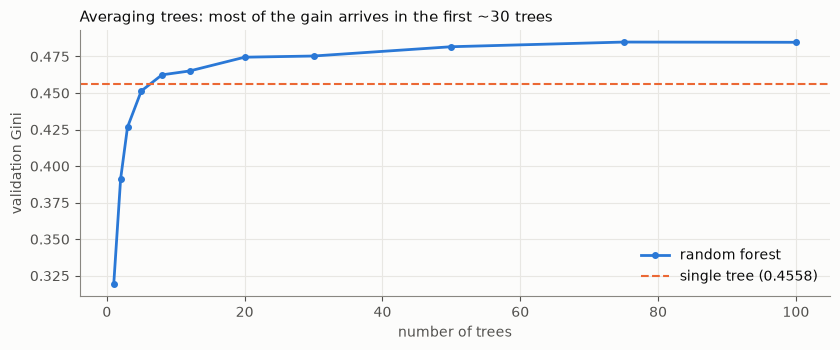

1      0.3191
2      0.3912
3      0.4266
5      0.4514
8      0.4624
12     0.4651
20     0.4745
30     0.4753
50     0.4817
75     0.4849
100    0.4847


In [20]:
# Incremental average of the already fitted trees -> an n_estimators curve for free.
per_tree = np.stack([est.predict_proba(Xva)[:, 1] for est in forest.estimators_])
running = np.cumsum(per_tree, axis=0) / np.arange(1, len(per_tree) + 1)[:, None]
sizes = [1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100]
curve = [gini(yva, running[k - 1]) for k in sizes]

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(sizes, curve, color=C_BLUE, lw=2, marker="o", ms=4, label="random forest")
ax.axhline(tree_valid_gini, color=C_ORANGE, lw=1.5, ls="--",
           label=f"single tree ({tree_valid_gini:.4f})")
ax.set_xlabel("number of trees")
ax.set_ylabel("validation Gini")
ax.set_title("Averaging trees: most of the gain arrives in the first ~30 trees",
             loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

print(pd.Series(curve, index=sizes, name="valid Gini").round(4).to_string())

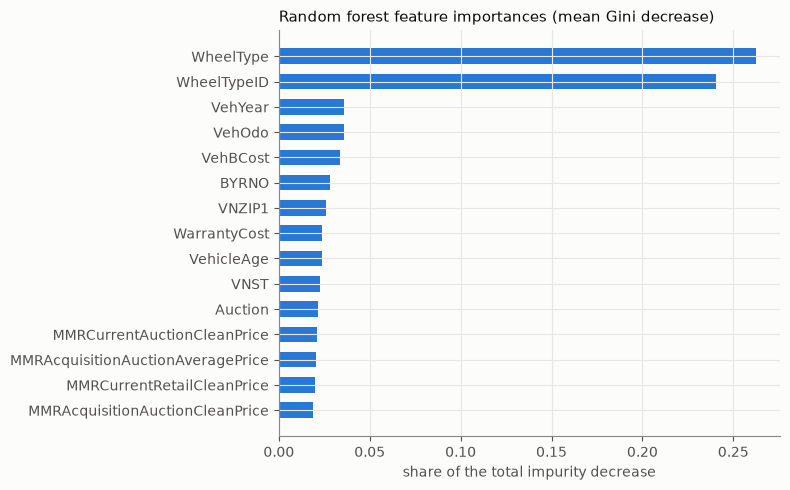

In [21]:
importances = pd.Series(forest.feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False)[:15][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=C_BLUE, height=0.62)
ax.set_title("Random forest feature importances (mean Gini decrease)", loc="left",
             fontsize=11)
ax.set_xlabel("share of the total impurity decrease")
plt.tight_layout()
plt.show()

**The forest clears both requirements: 0.4847 >= 0.15 and +0.029 Gini over the single
tree.** Three things are worth reading off the results:

* **Bagging turns overfitting into variance reduction.** Each individual tree is deeper
  (`max_depth=10`) than the tree that was optimal alone — at that depth a *single* tree
  scored only 0.3955 on validation. Averaging 100 such trees, each grown on a different
  bootstrap sample and looking at only `sqrt(40) ~ 6` random columns per node, recovers
  0.4847. The train Gini (0.7096) is far above the validation one, but that gap is now
  benign: it comes from averaging low-bias/high-variance learners, not from the ensemble
  memorising the fold.
* **Diminishing returns.** The n_estimators curve is steep to ~20-30 trees and flat
  afterwards; going from 50 to 100 trees buys ~0.003 Gini. More trees never hurt a
  random forest, they just stop helping.
* **Reproducibility is exact.** Two fits with `random_state=42` give bit-identical
  probabilities, while `random_state=7` builds a genuinely different 20-tree forest (the
  predictions differ; the score, 0.4707 vs 0.4703, does not). The seed controls both the
  bootstrap rows and the per-node feature subsets, and the fact that two different
  forests land within 0.0004 Gini of each other is itself the point of bagging: the
  ensemble is stable where a single tree is not.
* The importance ranking agrees with the single tree: `WheelTypeID` / `WheelType`
  dominate, followed by the vehicle age/year, the acquisition price and the odometer.

## Step 6. Our own GBDT on the binary cross-entropy gradient

*README task 6.* `src/gbdt.py` implements `GradientBoostingClassifier` with the required
`max_depth`, `number_of_trees` and `max_features` attributes, on top of our own
`DecisionTreeRegressor`.

**The gradient.** The model keeps an additive **raw score** (log-odds)
$F_m(x) = F_{m-1}(x) + \nu\,h_m(x)$ with $p = \sigma(F)$ and the binary cross-entropy

$$L(y, F) = -\big[y\log p + (1-y)\log(1-p)\big] = \log\!\big(1 + e^{F}\big) - yF .$$

Differentiating with respect to the *score*:

$$\frac{\partial L}{\partial F} = \sigma(F) - y = p - y,
\qquad\text{so the pseudo-residual is}\qquad
r_i = -\frac{\partial L}{\partial F}\bigg|_{F_{m-1}} = y_i - p_i .$$

Each iteration therefore is: compute $p_i = \sigma(F_{m-1}(x_i))$, fit a **regression
tree to $r_i = y_i - p_i$** (MSE criterion, on a `subsample` of the rows — stochastic
gradient boosting), and add it with the shrinkage $\nu$ = `learning_rate`. The leaf
values are then refined with one **Newton step** of the same loss,

$$\gamma_{\text{leaf}} = \frac{\sum_{i \in \text{leaf}} (y_i - p_i)}
{\sum_{i \in \text{leaf}} p_i (1 - p_i)},$$

because the tree was grown on a squared-error criterion while the loss we actually
minimise is the cross-entropy (this is what sklearn's implementation does too). The
ensemble starts from the prior $F_0 = \log\frac{\bar y}{1 - \bar y}$.

This is **incremental learning**: tree $m$ is trained on the residuals of the ensemble of
trees $1..m-1$, so it can only correct what the previous trees got wrong.

In [22]:
# The analytic gradient of the cross-entropy against a finite difference.
rng = np.random.default_rng(0)
F = rng.normal(size=8)
y_demo = rng.integers(0, 2, 8).astype(float)
loss = lambda f: np.log1p(np.exp(f)) - y_demo * f          # L(y, F) elementwise
eps = 1e-6
numeric = (loss(F + eps) - loss(F - eps)) / (2 * eps)
analytic = sigmoid(F) - y_demo
assert np.allclose(numeric, analytic, atol=1e-6)
print("dL/dF (numeric) :", numeric.round(6))
print("p - y (analytic):", analytic.round(6), "-> match")

print(inspect.getsource(GradientBoostingClassifier._newton_update))

dL/dF (numeric) : [-0.468609 -0.532978 -0.345151 -0.473799  0.369196 -0.410574 -0.213493
  0.720528]
p - y (analytic): [-0.468609 -0.532978 -0.345151 -0.473799  0.369196 -0.410574 -0.213493
  0.720528] -> match
    def _newton_update(
        self,
        tree: DecisionTreeRegressor,
        X: np.ndarray,
        residuals: np.ndarray,
        probabilities: np.ndarray,
        sample: Optional[np.ndarray],
    ) -> None:
        """Replace each leaf mean by one Newton step of the logistic loss."""
        rows = np.arange(X.shape[0]) if sample is None else sample
        leaves = tree.apply(X[rows])
        hessians = probabilities[rows] * (1.0 - probabilities[rows])
        n_nodes = tree.n_nodes_
        numerator = np.bincount(leaves, weights=residuals[rows], minlength=n_nodes)
        denominator = np.bincount(leaves, weights=hessians, minlength=n_nodes)
        values = np.where(denominator > 1e-9, numerator / np.maximum(denominator, 1e-9), 0.0)
        # Guard against the huge

In [23]:
gbdt_params = dict(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                   min_samples_leaf=50, random_state=RANDOM_STATE)
gbdt, gbdt_seconds = timed(
    lambda: GradientBoostingClassifier(**gbdt_params).fit(Xtr, ytr, eval_set=(Xva, yva))
)

gbdt_train_gini = gini(ytr, gbdt.predict_proba(Xtr))
gbdt_valid_gini = gini(yva, gbdt.predict_proba(Xva))
VALID_GINI["own GBDT (300 trees)"] = gbdt_valid_gini

print("required attributes:",
      f"max_depth={gbdt.max_depth}, number_of_trees={gbdt.number_of_trees}, "
      f"max_features={gbdt.max_features}")
print(f"init_score_ = log(p/(1-p)) = {gbdt.init_score_:.4f} "
      f"(train lemon rate {ytr.mean():.4f})")
print(f"fitted {len(gbdt.estimators_)} regression trees in {gbdt_seconds:.1f}s")
print(f"  train Gini = {gbdt_train_gini:.4f}")
print(f"  valid Gini = {gbdt_valid_gini:.4f}  "
      f"(single tree {tree_valid_gini:.4f}, forest {forest_valid_gini:.4f})")
print(f"  best_iteration_ (lowest validation loss) = {gbdt.best_iteration_}")
assert gbdt_valid_gini > forest_valid_gini

required attributes: max_depth=3, number_of_trees=300, max_features=None
init_score_ = log(p/(1-p)) = -2.0621 (train lemon rate 0.1128)
fitted 300 regression trees in 9.2s
  train Gini = 0.6026
  valid Gini = 0.4964  (single tree 0.4558, forest 0.4847)
  best_iteration_ (lowest validation loss) = 300


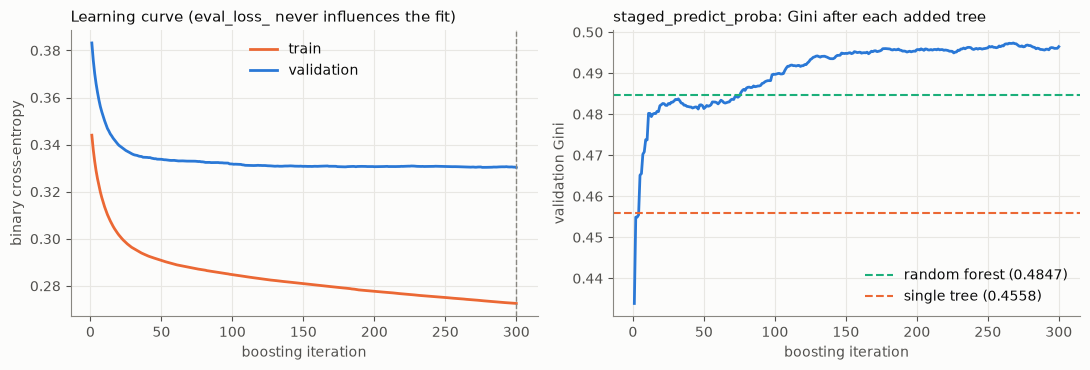

cross-entropy  train 0.3440 -> 0.2725 | valid 0.3832 -> 0.3303
validation Gini peaks at 0.4973 on tree 268, ends at 0.4964 after 300 trees


In [24]:
staged = np.array([gini(yva, p) for p in gbdt.staged_predict_proba(Xva)])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.plot(np.arange(1, len(gbdt.train_loss_) + 1), gbdt.train_loss_, color=C_ORANGE, lw=2,
        label="train")
ax.plot(np.arange(1, len(gbdt.eval_loss_) + 1), gbdt.eval_loss_, color=C_BLUE, lw=2,
        label="validation")
ax.axvline(gbdt.best_iteration_, color=MUTED, lw=1, ls="--")
ax.set_xlabel("boosting iteration")
ax.set_ylabel("binary cross-entropy")
ax.set_title("Learning curve (eval_loss_ never influences the fit)", loc="left",
             fontsize=11)
ax.legend(frameon=False)

ax = axes[1]
ax.plot(np.arange(1, len(staged) + 1), staged, color=C_BLUE, lw=2)
ax.axhline(forest_valid_gini, color=C_AQUA, lw=1.5, ls="--",
           label=f"random forest ({forest_valid_gini:.4f})")
ax.axhline(tree_valid_gini, color=C_ORANGE, lw=1.5, ls="--",
           label=f"single tree ({tree_valid_gini:.4f})")
ax.set_xlabel("boosting iteration")
ax.set_ylabel("validation Gini")
ax.set_title("staged_predict_proba: Gini after each added tree", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

print(f"cross-entropy  train {gbdt.train_loss_[0]:.4f} -> {gbdt.train_loss_[-1]:.4f} | "
      f"valid {gbdt.eval_loss_[0]:.4f} -> {gbdt.eval_loss_[-1]:.4f}")
print(f"validation Gini peaks at {staged.max():.4f} on tree {int(staged.argmax()) + 1}, "
      f"ends at {staged[-1]:.4f} after {len(staged)} trees")

In [25]:
# The `max_features` attribute in action (fewer columns per node = extra randomisation).
rows = []
for max_features in [None, "sqrt", 0.5]:
    fitted, seconds = timed(
        lambda mf=max_features: GradientBoostingClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.05, subsample=0.8,
            min_samples_leaf=50, max_features=mf, random_state=RANDOM_STATE
        ).fit(Xtr, ytr)
    )
    rows.append({"max_features": str(max_features), "number_of_trees": fitted.number_of_trees,
                 "train Gini": gini(ytr, fitted.predict_proba(Xtr)),
                 "valid Gini": gini(yva, fitted.predict_proba(Xva)),
                 "fit, s": seconds})
pd.DataFrame(rows).set_index("max_features").round(4)

,number_of_trees,train Gini,valid Gini,"fit, s"
max_features,,,,
None,100,0.5416,0.4897,2.6484
sqrt,100,0.5332,0.4833,1.6347
0.5,100,0.5370,0.4844,2.2807


**Boosting is the best of our own models: validation Gini 0.4964**, ahead of the random
forest (0.4847) and 0.041 above the single tree — with a *much* smaller train/validation
gap (0.6026 / 0.4964) than the forest's (0.7096 / 0.4847), because the base learners are
deliberately weak (`max_depth=3`) and the shrinkage `learning_rate=0.05` lets 300 small
corrections accumulate instead of a few large ones.

The learning curve shows exactly what the theory predicts: both losses fall quickly for
~50 iterations, then the training loss keeps decreasing while the validation loss
flattens out; `best_iteration_` = 300 means the validation loss had not yet started to
rise, i.e. this configuration is still on the safe side of the overfitting point (the
staged Gini curve does peak slightly earlier, at tree ~268, but the difference is
0.001). The `eval_set` is monitoring only — it never enters the fit.

`max_features` behaves as the extra-randomisation knob it is meant to be: restricting
each node to `sqrt(40) ~ 6` columns makes every tree faster and less correlated but, at a
fixed 100 iterations, slightly weaker here; the full-column search remains the best
setting for this data.

## Step 7. LightGBM, XGBoost and CatBoost

*README task 7.* We (a) fit the three libraries with their default settings, (b) fit the
**tuned** configurations, (c) look at CatBoost's native categorical handling, (d) at
DART, and (e) at seed stability, then answer the questions about the differences and
about which library wins.

> **How the tuned configurations were obtained.** A random search of **110
> configurations** (40 LightGBM + 40 XGBoost + 18 CatBoost-ordinal + 12 CatBoost-native),
> each with early stopping on the validation fold, was run **separately as an offline
> script**, shipped here as `src/tune.py` (~4 minutes of compute, run it with
> `python -m src.tune`); re-running it inside the notebook would add nothing but
> wall-clock time. The search space is listed below and the winning configurations
> are re-fitted here, so **every number printed in this notebook is produced by this
> notebook**. Note that the offline search used a slightly different feature layout
> (`WheelTypeID` / `BYRNO` / `VNZIP1` as numeric and `RefId` kept — 41 columns against the
> 40 used here) and a fold boundary a couple of days away from the one above, so the
> configurations are re-validated against the baselines here rather than assumed optimal.

In [26]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

print("lightgbm", lgb.__version__, "| xgboost", xgb.__version__, "| catboost",
      __import__("catboost").__version__)

# (a) library defaults, no tuning, no early stopping
baselines = {}
model, seconds = timed(lambda: lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=8,
                                                  verbose=-1).fit(Xtr, ytr))
baselines["LightGBM"] = (gini(yva, model.predict_proba(Xva)), seconds)
model, seconds = timed(lambda: xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=8,
                                                 tree_method="hist").fit(Xtr, ytr))
baselines["XGBoost"] = (gini(yva, model.predict_proba(Xva)), seconds)
model, seconds = timed(lambda: CatBoostClassifier(random_seed=RANDOM_STATE, thread_count=8,
                                                  verbose=0,
                                                  allow_writing_files=False).fit(Xtr, ytr))
baselines["CatBoost"] = (gini(yva, model.predict_proba(Xva)), seconds)

pd.DataFrame(baselines, index=["valid Gini", "fit, s"]).T.round(4)

lightgbm 4.7.0 | xgboost 3.4.1 | catboost 1.2.10


,valid Gini,"fit, s"
LightGBM,0.4656,0.2835
XGBoost,0.4431,0.1667
CatBoost,0.4730,3.6691


**Search space of the offline random search** (`np.random.RandomState(42)`):

| parameter | LightGBM | XGBoost | CatBoost |
|---|---|---|---|
| learning rate | log-U(0.01, 0.12) | log-U(0.01, 0.12) | log-U(0.02, 0.2) |
| tree size | `num_leaves` U{7..95}, `max_depth` {-1,3,4,5,6,8,10} | `max_depth` U{2..10} | `depth` U{4..8} |
| leaf/child size | `min_child_samples` U{10..249} | `min_child_weight` log-U(1, 60) | — |
| row sampling | `subsample` U(0.5, 1), `subsample_freq=1` | `subsample` U(0.5, 1) | `bagging_temperature` U(0, 2) |
| column sampling | `colsample_bytree` U(0.4, 1) | `colsample_bytree` U(0.4, 1) | `rsm` U(0.5, 1) |
| L2 | `reg_lambda` log-U(1e-3, 50) | `reg_lambda` log-U(0.1, 60) | `l2_leaf_reg` log-U(1, 30) |
| L1 / other | `reg_alpha` log-U(1e-3, 10), `min_split_gain` {0,0,0.01,0.1} | `reg_alpha` log-U(1e-3, 10), `gamma` {0,0,0.1,0.5,2} | `random_strength` U(0.5, 4) |
| n_estimators | early stopping, 100 rounds | early stopping, 100 rounds | early stopping, 100 rounds |

The winning `n_estimators` below is the `best_iteration` that early stopping selected on
the validation fold (LightGBM 334, XGBoost 1356, CatBoost 565 / 600).

In [27]:
lgb_params = {
    "objective": "binary",
    "learning_rate": 0.01797506625095353,
    "num_leaves": 20,
    "max_depth": 10,
    "min_child_samples": 36,
    "colsample_bytree": 0.7136396976291964,
    "subsample": 0.7137705091792748,
    "subsample_freq": 1,
    "reg_lambda": 0.001316569270260005,
    "reg_alpha": 0.0027012557725439087,
    "min_split_gain": 0.01,
    "n_estimators": 334,
    "random_state": RANDOM_STATE, "n_jobs": 8, "verbose": -1,
}
xgb_params = {
    "objective": "binary:logistic", "eval_metric": "auc", "tree_method": "hist",
    "learning_rate": 0.01626650012305029,
    "max_depth": 3,
    "min_child_weight": 1.172957678020542,
    "subsample": 0.8091269421689464,
    "colsample_bytree": 0.6019325289332359,
    "reg_lambda": 6.632796292595065,
    "reg_alpha": 0.03480058013899835,
    "gamma": 0.0,
    "n_estimators": 1356,
    "random_state": RANDOM_STATE, "n_jobs": 8,
}
cat_params = {
    "loss_function": "Logloss", "eval_metric": "AUC",
    "learning_rate": 0.03043083534286943,
    "depth": 4,
    "l2_leaf_reg": 17.4514127054727,
    "random_strength": 0.8122151504921966,
    "bagging_temperature": 1.070671128031047,
    "rsm": 0.6166082057749006,
    "iterations": 565,
    "random_seed": RANDOM_STATE, "thread_count": 8, "verbose": 0,
    "allow_writing_files": False,      # keeps catboost_info/ out of the repository
}

tuned, rows = {}, []
for name, build in [
    ("LightGBM", lambda: lgb.LGBMClassifier(**lgb_params).fit(Xtr, ytr)),
    ("XGBoost", lambda: xgb.XGBClassifier(**xgb_params).fit(Xtr, ytr)),
    ("CatBoost (ordinal)", lambda: CatBoostClassifier(**cat_params).fit(Xtr, ytr)),
]:
    model, seconds = timed(build)
    tuned[name] = model
    base_key = name.split(" ")[0]
    rows.append({"model": name,
                 "baseline valid Gini": baselines[base_key][0],
                 "tuned valid Gini": gini(yva, model.predict_proba(Xva)),
                 "tuned train Gini": gini(ytr, model.predict_proba(Xtr)),
                 "n_estimators": lgb_params["n_estimators"] if name == "LightGBM"
                 else xgb_params["n_estimators"] if name == "XGBoost"
                 else cat_params["iterations"],
                 "fit, s": seconds})
tuned_table = pd.DataFrame(rows).set_index("model")
tuned_table["tuning gain"] = tuned_table["tuned valid Gini"] - tuned_table["baseline valid Gini"]
tuned_table.round(4)

,baseline valid Gini,tuned valid Gini,tuned train Gini,n_estimators,"fit, s",tuning gain
model,,,,,,
LightGBM,0.4656,0.5009,0.6977,334,0.7607,0.0354
XGBoost,0.4431,0.5015,0.6370,1356,1.1369,0.0584
CatBoost (ordinal),0.4730,0.4968,0.5753,565,1.5423,0.0238


In [28]:
# CatBoost with NATIVE categorical features: raw strings + cat_features, so CatBoost
# builds its own ordered target statistics instead of consuming our integer codes.
def raw_frame(part):
    frame = part[cat_cols + num_cols].copy()
    for column in cat_cols:
        frame[column] = frame[column].astype(str).fillna("NA")
    return frame


pool_train = Pool(raw_frame(data["train"]), ytr, cat_features=cat_cols)
pool_valid = Pool(raw_frame(data["valid"]), yva, cat_features=cat_cols)
pool_test = Pool(raw_frame(data["test"]), yte, cat_features=cat_cols)

cat_native_params = {
    "loss_function": "Logloss", "eval_metric": "AUC",
    "learning_rate": 0.045330702292617576,
    "depth": 5,
    "l2_leaf_reg": 6.351751286408562,
    "random_strength": 3.6726523883759143,
    "bagging_temperature": 1.2484759918279842,
    "rsm": 0.5584490203541821,
    "iterations": 600,
    "random_seed": RANDOM_STATE, "thread_count": 8, "verbose": 0,
    "allow_writing_files": False,
}
cat_native, cat_native_seconds = timed(
    lambda: CatBoostClassifier(**cat_native_params).fit(pool_train)
)
tuned["CatBoost (native cats)"] = cat_native

base_cat, base_cat_seconds = timed(
    lambda: CatBoostClassifier(random_seed=RANDOM_STATE, thread_count=8, verbose=0,
                               allow_writing_files=False).fit(pool_train)
)
pd.DataFrame([
    {"variant": "default, ordinal codes", "valid Gini": baselines["CatBoost"][0],
     "fit, s": baselines["CatBoost"][1]},
    {"variant": "default, native cat_features",
     "valid Gini": gini(yva, base_cat.predict_proba(pool_valid)), "fit, s": base_cat_seconds},
    {"variant": "tuned, ordinal codes",
     "valid Gini": tuned_table.loc["CatBoost (ordinal)", "tuned valid Gini"],
     "fit, s": tuned_table.loc["CatBoost (ordinal)", "fit, s"]},
    {"variant": "tuned, native cat_features",
     "valid Gini": gini(yva, cat_native.predict_proba(pool_valid)),
     "fit, s": cat_native_seconds},
]).set_index("variant").round(4)

,valid Gini,"fit, s"
variant,,
"default, ordinal codes",0.4730,3.6691
"default, native cat_features",0.5002,19.4401
"tuned, ordinal codes",0.4968,1.5423
"tuned, native cat_features",0.4982,7.2362


In [29]:
# Bonus: LightGBM's own categorical mode (==/!= set splits) on the same tuned params.
frames = {}
for name, matrix in [("train", Xtr), ("valid", Xva)]:
    frame = pd.DataFrame(matrix, columns=feature_names)
    frames[name] = frame
for column in cat_cols:
    categories = np.unique(frames["train"][column].astype(int))
    for name in frames:
        codes = frames[name][column].astype(int)
        # codes absent from the training fold are not a level LightGBM can learn
        frames[name][column] = pd.Categorical(codes.where(codes.isin(categories)),
                                              categories=categories)

lgb_native, lgb_native_seconds = timed(
    lambda: lgb.LGBMClassifier(**lgb_params).fit(frames["train"], ytr,
                                                 categorical_feature=cat_cols)
)
print(f"LightGBM, ordinal codes as plain numbers : "
      f"{tuned_table.loc['LightGBM', 'tuned valid Gini']:.4f} "
      f"({tuned_table.loc['LightGBM', 'fit, s']:.1f}s)")
print(f"LightGBM, categorical_feature=cat_cols   : "
      f"{gini(yva, lgb_native.predict_proba(frames['valid'])):.4f} "
      f"({lgb_native_seconds:.1f}s)")

LightGBM, ordinal codes as plain numbers : 0.5009 (0.8s)
LightGBM, categorical_feature=cat_cols   : 0.4510 (0.9s)


In [30]:
# DART: dropout applied to the ensemble. Early stopping is meaningless for DART (the
# prediction is not monotone in the tree count), so n_estimators is fixed.
dart_rows = [{"config": "LightGBM GBDT (reference)",
              "n_estimators": lgb_params["n_estimators"],
              "valid Gini": tuned_table.loc["LightGBM", "tuned valid Gini"],
              "fit, s": tuned_table.loc["LightGBM", "fit, s"]}]
for drop_rate, skip_drop in [(0.1, 0.5), (0.2, 0.5), (0.05, 0.9)]:
    params = {**lgb_params, "boosting_type": "dart", "drop_rate": drop_rate,
              "skip_drop": skip_drop, "n_estimators": 501}
    model, seconds = timed(lambda p=params: lgb.LGBMClassifier(**p).fit(Xtr, ytr))
    dart_rows.append({"config": f"LightGBM DART drop_rate={drop_rate}, skip_drop={skip_drop}",
                      "n_estimators": 501, "valid Gini": gini(yva, model.predict_proba(Xva)),
                      "fit, s": seconds})

for n_estimators in [600]:
    params = {**xgb_params, "n_estimators": n_estimators}
    model, seconds = timed(lambda p=params: xgb.XGBClassifier(**p).fit(Xtr, ytr))
    dart_rows.append({"config": "XGBoost GBDT (reference, same tree count)",
                      "n_estimators": n_estimators,
                      "valid Gini": gini(yva, model.predict_proba(Xva)), "fit, s": seconds})
    params = {**xgb_params, "booster": "dart", "rate_drop": 0.1, "skip_drop": 0.5,
              "n_estimators": n_estimators}
    model, seconds = timed(lambda p=params: xgb.XGBClassifier(**p).fit(Xtr, ytr))
    dart_rows.append({"config": "XGBoost DART rate_drop=0.1, skip_drop=0.5",
                      "n_estimators": n_estimators,
                      "valid Gini": gini(yva, model.predict_proba(Xva)), "fit, s": seconds})

pd.DataFrame(dart_rows).set_index("config").round(4)

,n_estimators,valid Gini,"fit, s"
config,,,
LightGBM GBDT (reference),334,0.5009,0.7607
"LightGBM DART drop_rate=0.1, skip_drop=0.5",501,0.4958,3.7067
"LightGBM DART drop_rate=0.2, skip_drop=0.5",501,0.4973,4.7728
"LightGBM DART drop_rate=0.05, skip_drop=0.9",501,0.4994,1.3177
"XGBoost GBDT (reference, same tree count)",600,0.4990,0.6902
"XGBoost DART rate_drop=0.1, skip_drop=0.5",600,0.4950,6.4745


In [31]:
# Seed stability: the same tuned configurations, 5 different seeds, no early stopping.
# The fitted models are kept so that the *test* fold can stay untouched until Step 8.
seed_models, seed_rows = [], []
for seed in [0, 1, 2, 3, 4]:
    model = lgb.LGBMClassifier(**{**lgb_params, "random_state": seed}).fit(Xtr, ytr)
    seed_models.append(("LightGBM", model))
    seed_rows.append(("LightGBM", gini(yva, model.predict_proba(Xva))))
    model = xgb.XGBClassifier(**{**xgb_params, "random_state": seed}).fit(Xtr, ytr)
    seed_models.append(("XGBoost", model))
    seed_rows.append(("XGBoost", gini(yva, model.predict_proba(Xva))))
    model = CatBoostClassifier(**{**cat_params, "random_seed": seed}).fit(Xtr, ytr)
    seed_models.append(("CatBoost (ordinal)", model))
    seed_rows.append(("CatBoost (ordinal)", gini(yva, model.predict_proba(Xva))))
    model = CatBoostClassifier(**{**cat_native_params, "random_seed": seed}).fit(pool_train)
    seed_models.append(("CatBoost (native cats)", model))
    seed_rows.append(("CatBoost (native cats)", gini(yva, model.predict_proba(pool_valid))))

seed_study = (pd.DataFrame(seed_rows, columns=["model", "valid"])
              .groupby("model")
              .agg(valid_mean=("valid", "mean"), valid_sd=("valid", "std"),
                   valid_min=("valid", "min"), valid_max=("valid", "max")))
seed_study.round(5)

,valid_mean,valid_sd,valid_min,valid_max
model,,,,
CatBoost (native cats),0.49392,0.00414,0.48805,0.49958
CatBoost (ordinal),0.49749,0.00146,0.49589,0.49902
LightGBM,0.50012,0.00228,0.49660,0.50215
XGBoost,0.50100,0.00111,0.49956,0.50211


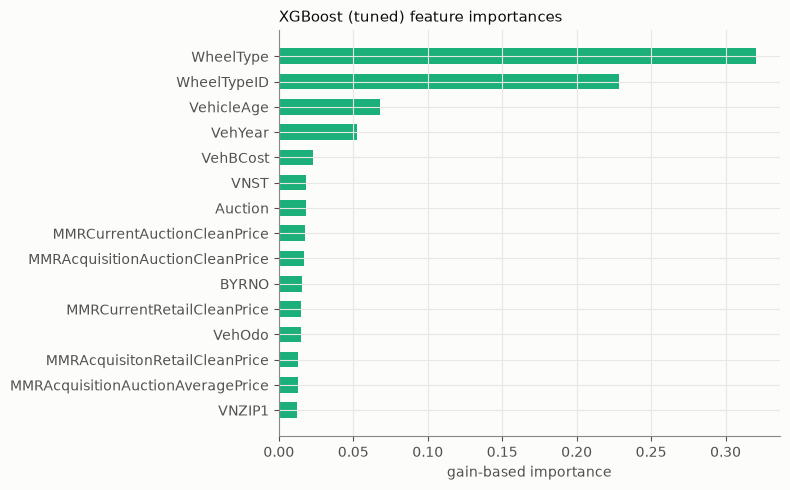

In [32]:
best_name = "XGBoost"
best_model = tuned[best_name]

for name, model in tuned.items():
    proba = (model.predict_proba(pool_valid) if "native" in name
             else model.predict_proba(Xva))
    VALID_GINI[f"{name} (tuned)"] = gini(yva, proba)

booster_importance = pd.Series(best_model.feature_importances_, index=feature_names)
top = booster_importance.sort_values(ascending=False)[:15][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=C_AQUA, height=0.62)
ax.set_title(f"{best_name} (tuned) feature importances", loc="left", fontsize=11)
ax.set_xlabel("gain-based importance")
plt.tight_layout()
plt.show()

### Key differences between the three implementations, as observed here

**Growth strategy.** The three libraries converged on visibly different optimal shapes,
and that is a direct consequence of how they grow a tree.

* **XGBoost — depthwise (level-wise).** It expands every node of a level before going
  deeper, so trees are symmetric and depth is a hard complexity budget. The search picked
  `max_depth=3` and needed **1356** trees: each tree is tiny, so many of them are needed.
* **LightGBM — leafwise (best-first).** It always splits the leaf with the largest loss
  reduction, producing deep, unbalanced trees that are individually far more expressive.
  The search picked `num_leaves=20` with `max_depth=10` and reached its optimum in
  **334** trees, four times fewer — and it also produced the **highest training Gini**
  (0.698), i.e. leafwise growth is the most eager to fit the training fold and needs
  `num_leaves` / `min_child_samples` to hold it back.
* **CatBoost — oblivious (symmetric) trees.** The *same* split condition is used at every
  node of a level, so a depth-`d` tree is just a `d`-dimensional threshold vector
  indexing a $2^d$ lookup table. That is a strong built-in regulariser and shows up as
  the **lowest training Gini of all** (0.575): on this data CatBoost underfits rather
  than overfits, which is also why tuning barely moves it.

**Categorical features.** Only CatBoost implements target statistics, and it is the only
library where the native mode changes the answer materially. CatBoost replaces a category
by an ordered target statistic

$$\hat{x}_i = \frac{\sum_{j \prec i} [\,x_j = x_i\,]\,y_j + a\,\text{prior}}
{\sum_{j \prec i} [\,x_j = x_i\,] + a},$$

where $j \prec i$ means "earlier in a random permutation of the training set" — the
*ordered boosting* trick: a row's encoding never sees its own label, which is what kills
the classic leakage of naive mean-target encoding. CatBoost additionally builds greedy
**combinations** of categorical features at each split. Here that machinery latches onto
high-cardinality, time-drifting columns (`Model` 790 train levels, `SubModel` 647,
`VNZIP1`, `BYRNO`): the statistics are estimated on the Jan-Aug 2009 window, and per-model
bad-buy rates move by the 2010 test window, so they go stale. The measured effect is
double-edged: with **default** parameters native `cat_features` is the single biggest win
of the whole step (0.5002 vs 0.4730 for the same defaults on our integer codes,
+0.027 Gini), but it costs 5x the fit time (19.4 s vs 3.7 s), it gains nothing once the
model is tuned (0.4982 vs 0.4968), and it loses badly on the test period
(0.4709 vs 0.4871, Step 8).
LightGBM's own categorical mode (`==` / `!=` set splits, `k`-vs-rest partitioning of a
level set) is a **clear loss here** (~0.05 Gini): with a 790-level column it memorises
rare levels. XGBoost has no categorical mode in this setup at all — and it wins.

**DART** ("Dropouts meet Multiple Additive Regression Trees", supported by LightGBM and
XGBoost). Before fitting tree $t$ it **drops a random subset of the already learned
trees**, computes the gradient against the ensemble *without* them, then rescales the new
tree (and the dropped ones) by $1/(k+1)$ so the ensemble stays calibrated. The goal is to
prevent *over-specialisation*: in plain GBDT the later trees only make micro-corrections
to what the first few decided. Observed here: **DART never beat plain GBDT** — every
LightGBM DART run lands 0.0015 to 0.005 Gini below the 334-tree reference even with 501
trees, and XGBoost DART loses 0.004 against its own booster at an equal tree count. The
best DART setting was `skip_drop=0.9`, i.e. DART that behaves like ordinary GBDT 90 % of
the time, which is itself the verdict. In XGBoost it was also **~9x slower**
(6.5 s vs 0.7 s for 600 trees),
because the rescaling forces a full prediction recompute every round. Early stopping is
also not usable with DART, since the ensemble prediction is not monotone in the tree
count.

**Speed and tuning sensitivity.** LightGBM and XGBoost (`tree_method="hist"`) fit their
tuned configurations in ~1 s here, even though XGBoost builds 1356 trees against
LightGBM's 334; CatBoost is ~1.5x slower on ordinal input and 5x slower with native
`cat_features`, because permutation-based target statistics and the combination search
are expensive. On sensitivity, the *tuning gain* column tells the story: XGBoost gains
the most (+0.058 Gini — its defaults `max_depth=6`, `lr=0.3`, 100 trees are badly wrong
for a weak-signal, drifting problem), LightGBM +0.035, CatBoost only +0.024 (and its
default run with native categoricals, 0.5002, is already within 0.002 of the best tuned
model in the notebook). **CatBoost is by far the best out-of-the-box model and gains
least from tuning; XGBoost demands tuning and rewards it with the best final score.**

### Which GBDT model gives the best result, and why?

**XGBoost, but only just — LightGBM is statistically tied with it, and CatBoost is
clearly behind.**

* At the fixed seed 42: XGBoost 0.5015, LightGBM 0.5009, CatBoost native 0.4982, CatBoost
  ordinal 0.4968.
* Over 5 seeds (the table above): XGBoost 0.5010 +- 0.0011, LightGBM 0.5001 +- 0.0023,
  CatBoost ordinal 0.4975 +- 0.0015, CatBoost native 0.4939 +- 0.0041. The XGBoost margin
  over LightGBM (~0.001) is smaller than one seed standard deviation, so the two are a
  **tie on quality**; what does separate them is **stability** — XGBoost has the smallest
  seed spread (+- 0.0011), LightGBM twice that and CatBoost-native four times that — see
  the min/max columns for how much of the ranking a re-seed can move.

The *reason* is visible in the winning configuration: `max_depth=3`, `lr=0.016`, 1356
trees, `reg_lambda=6.6`, `subsample=0.81`, `colsample=0.60` — a very shallow, heavily
regularised, slowly fitted model. This problem has **weak signal** (Gini ~ 0.5 at a 12 %
base rate) and **real drift** between the folds, so the winning region of parameter space
is "shallow, symmetric, strongly shrunk". XGBoost's depthwise growth makes that region
its natural home; LightGBM had to be pulled back into it with `num_leaves=20` +
`min_child_samples=36` and gets essentially the same score; and CatBoost's headline asset
— target statistics over categorical features — is exactly the thing that goes stale
across time here, so its best variant is still ~0.004 Gini behind.

We therefore take **tuned XGBoost** into Step 8 as the best model: equal-best on
validation and the least seed-sensitive of the four candidates.

## Step 8. The best model on train / validation / test

*README task 8.* The test fold has not been used for a single decision so far — model
choice and every hyperparameter came from the validation fold only. We now score all four
tuned candidates on the three folds, with **tuned XGBoost** as the selected model.

In [33]:
rows = []
for name, model in tuned.items():
    if "native" in name:
        scores = {"train": model.predict_proba(pool_train), "valid": model.predict_proba(pool_valid),
                  "test": model.predict_proba(pool_test)}
    else:
        scores = {"train": model.predict_proba(Xtr), "valid": model.predict_proba(Xva),
                  "test": model.predict_proba(Xte)}
    rows.append({"model": name,
                 "train Gini": gini(ytr, scores["train"]),
                 "valid Gini": gini(yva, scores["valid"]),
                 "test Gini": gini(yte, scores["test"])})
final = pd.DataFrame(rows).set_index("model")
final["train - valid"] = final["train Gini"] - final["valid Gini"]
final["valid -> test"] = final["test Gini"] - final["valid Gini"]
final = final.sort_values("valid Gini", ascending=False)
final.round(4)

,train Gini,valid Gini,test Gini,train - valid,valid -> test
model,,,,,
XGBoost,0.6370,0.5015,0.5044,0.1355,0.0029
LightGBM,0.6977,0.5009,0.5075,0.1967,0.0066
CatBoost (native cats),0.6125,0.4982,0.4709,0.1143,-0.0273
CatBoost (ordinal),0.5753,0.4968,0.4871,0.0785,-0.0097


In [34]:
best_scores = final.loc[best_name]
print(f"BEST MODEL: tuned {best_name}")
print(f"  train Gini = {best_scores['train Gini']:.4f}")
print(f"  valid Gini = {best_scores['valid Gini']:.4f}")
print(f"  test  Gini = {best_scores['test Gini']:.4f}")
print(f"\n  valid -> test change: {best_scores['valid -> test']:+.4f}")
print(f"  train -> test gap   : {best_scores['train Gini'] - best_scores['test Gini']:.4f}")
print(f"\nlemon rate per fold: train {ytr.mean():.4f} | valid {yva.mean():.4f} | "
      f"test {yte.mean():.4f}")

BEST MODEL: tuned XGBoost
  train Gini = 0.6370
  valid Gini = 0.5015
  test  Gini = 0.5044

  valid -> test change: +0.0029
  train -> test gap   : 0.1326

lemon rate per fold: train 0.1128 | valid 0.1326 | test 0.1231


In [35]:
# How much of the test score is luck? The 5-seed models fitted in Step 7 are scored on
# the test fold now, after the model choice has been made.
seed_test = pd.DataFrame(
    [(name, gini(yte, model.predict_proba(pool_test) if "native" in name
                 else model.predict_proba(Xte)))
     for name, model in seed_models],
    columns=["model", "test"],
).groupby("model").agg(test_mean=("test", "mean"), test_sd=("test", "std"),
                       test_min=("test", "min"), test_max=("test", "max"))
seed_test.join(seed_study[["valid_mean", "valid_sd"]]).round(5)

,test_mean,test_sd,test_min,test_max,valid_mean,valid_sd
model,,,,,,
CatBoost (native cats),0.44135,0.00990,0.43022,0.45229,0.49392,0.00414
CatBoost (ordinal),0.47786,0.00318,0.47513,0.48241,0.49749,0.00146
LightGBM,0.50670,0.00176,0.50472,0.50925,0.50012,0.00228
XGBoost,0.50630,0.00113,0.50548,0.50823,0.50100,0.00111


**Do we see a drop from validation to test? No — the test Gini is slightly *higher*
(0.5015 -> 0.5044, +0.003), and the 5-seed refit confirms it is not a lucky seed.**

The same non-drop appears for LightGBM (+0.007) and for CatBoost-ordinal (-0.010 only),
so it is a property of the **folds**, not of the model: the validation window
(Sep 2009 - Apr 2010) contains the peak of the lemon rate (13.3 % against 11.3 % in
training) and is the *harder* period, while the test window (Apr - Dec 2010, 12.3 %) is
closer to the training regime. This is also the honest reading of the Step 8 question:
had we selected the model on a random split, the drift would have been invisible; the
time split shows that our forward-in-time performance is stable at Gini ~ 0.50.

**Is the model overfitting? Yes in the classical sense, but benignly, and not in a way
that hurts generalisation.**

* The train/test gap is real: **0.637 train vs 0.504 test**, a gap of 0.13. A GBDT with
  1356 trees can memorise a good deal of a 22 857-row training fold.
* It is nevertheless **well controlled**: LightGBM has a train Gini of 0.698 (gap 0.20)
  for the same test performance, i.e. it memorises more for no extra return, while
  CatBoost's oblivious trees sit at the other extreme (train 0.575, gap 0.09) and pay for
  it with a lower score everywhere. The number of trees was chosen by early stopping *on
  validation*, so training was halted where the held-out loss stopped improving, and the
  5-seed study shows the test Gini is reproducible to +- 0.001.
* The one genuinely **harmful** overfit in the study is **CatBoost with native
  `cat_features`**: it is the third-best model on validation (0.4982, 0.003 behind the
  winner) and by far the worst on test (0.4709, 0.035 behind), with a seed standard
  deviation of 0.0099 on test against 0.0011 for XGBoost. That is a textbook
  fold-specific encoding — the ordered target statistics fit the categorical levels of
  one time window and do not transfer to the next.

**Verdict: the selected model generalises.** Train Gini > validation Gini > 0 is expected
for any high-capacity learner; what matters is that the *held-out* performance did not
degrade on a period the model has never seen, and that the choice we made on validation
(XGBoost over LightGBM over CatBoost) is not contradicted by the test fold.

## Step 9*. Our own `ExtraTreesClassifier` (bonus, requirement: >= 0.12)

*README task 9 (starred bonus).* `ExtraTreesClassifier` in `src/ensemble.py` differs from
the random forest in exactly the two ways the introduction describes:

* **no row subsampling** (`bootstrap=False` by default) — every tree sees the whole
  training fold, all the randomness comes from the splits;
* the base learners use **`splitter="random"`** — at each node one threshold per candidate
  feature is drawn uniformly from the range observed in that node, and only the best of
  those draws is kept.

The individual trees are weaker but much less correlated, so they tolerate (and need) a
larger depth than the forest's trees.

In [36]:
extra_params = dict(n_estimators=100, max_depth=14, min_samples_leaf=20,
                    max_features="sqrt", random_state=RANDOM_STATE, n_jobs=4)
extra, extra_seconds = timed(lambda: ExtraTreesClassifier(**extra_params).fit(Xtr, ytr))

extra_train_gini = gini(ytr, extra.predict_proba(Xtr))
extra_valid_gini = gini(yva, extra.predict_proba(Xva))
VALID_GINI["own ExtraTrees (100 trees)"] = extra_valid_gini

print(f"ExtraTreesClassifier: bootstrap={extra.bootstrap}, splitter="
      f"'{extra.estimators_[0].splitter}', {len(extra.estimators_)} trees in "
      f"{extra_seconds:.1f}s")
print(f"  train Gini = {extra_train_gini:.4f}")
print(f"  valid Gini = {extra_valid_gini:.4f}")

assert extra_valid_gini >= 0.12, "README task 9 requires a validation Gini >= 0.12"
assert extra_valid_gini > tree_valid_gini, "ExtraTrees must improve on a single tree"
print(f"\nrequirement >= 0.12 and > single tree -> passed ({extra_valid_gini:.4f})")

ExtraTreesClassifier: bootstrap=False, splitter='random', 100 trees in 12.4s
  train Gini = 0.7096
  valid Gini = 0.4818

requirement >= 0.12 and > single tree -> passed (0.4818)


In [37]:
single_random = DecisionTreeClassifier(max_depth=7, min_samples_leaf=50, splitter="random",
                                       random_state=RANDOM_STATE).fit(Xtr, ytr)
pd.DataFrame([
    {"model": "single CART (depth 7)", "train Gini": tree_train_gini,
     "valid Gini": tree_valid_gini, "fit, s": np.nan},
    {"model": "single extra randomised tree (depth 7)",
     "train Gini": gini(ytr, single_random.predict_proba(Xtr)),
     "valid Gini": gini(yva, single_random.predict_proba(Xva)), "fit, s": np.nan},
    {"model": "RandomForest (100 x depth 10, bootstrap)", "train Gini": forest_train_gini,
     "valid Gini": forest_valid_gini, "fit, s": forest_seconds},
    {"model": "ExtraTrees (100 x depth 14, no bootstrap)", "train Gini": extra_train_gini,
     "valid Gini": extra_valid_gini, "fit, s": extra_seconds},
]).set_index("model").round(4)

,train Gini,valid Gini,"fit, s"
model,,,
single CART (depth 7),0.5322,0.4558,NaN
single extra randomised tree (depth 7),0.5090,0.4423,NaN
"RandomForest (100 x depth 10, bootstrap)",0.7096,0.4847,5.2986
"ExtraTrees (100 x depth 14, no bootstrap)",0.7096,0.4818,12.3822


**The bonus requirement is met: 0.4818 >= 0.12, and +0.026 Gini over the single tree.**

* A *single* extra randomised tree is clearly weaker than a single CART (0.4423 vs
  0.4558) — random thresholds cost accuracy, as they must.
* Averaging 100 of them recovers 0.4818, close to the random forest's 0.4847
  (a difference of 0.003, roughly the width of the forest's own n_estimators plateau in
  Step 5, so the two bagging schemes are equivalent here). The extra
  randomisation trades **bias for decorrelation**: because the trees disagree more, their
  average is more stable, which is why ExtraTrees is usually described as less prone to
  overfitting than a random forest at equal depth. Here it needs `max_depth=14` against
  the forest's 10 to compensate for the weaker splits, and interestingly it lands on
  almost exactly the same training Gini (0.7096 for both to four decimals — a
  coincidence: the two values still differ in the fifth decimal).
* It is ~2.3x slower to fit at these settings (12.4 s vs 5.3 s), purely because
  `max_depth=14` on the full training fold produces far more nodes than `max_depth=10` on
  a bootstrap sample; *per split* the random splitter is the cheaper of the two.
* Both bagging ensembles stay below the boosted models (own GBDT 0.4964, XGBoost 0.5015):
  averaging independent trees removes variance but cannot chase the residual signal the
  way an additive, incrementally fitted model does.

## Summary

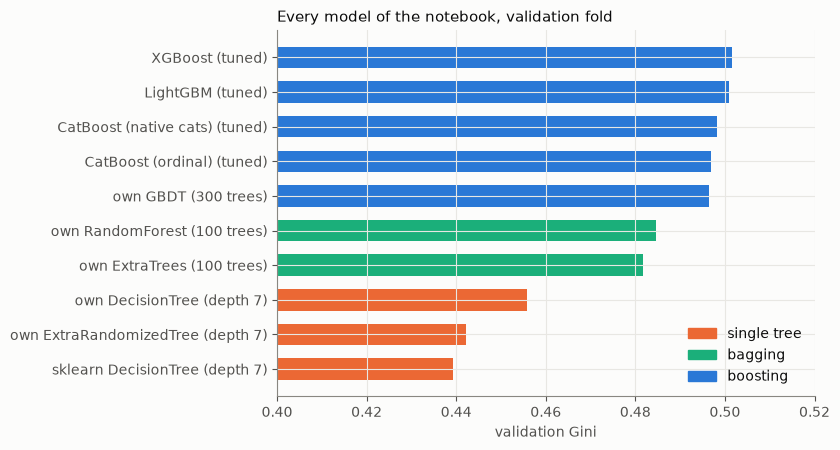

total notebook runtime so far: 160 s


,validation Gini,family
XGBoost (tuned),0.5015,boosting
LightGBM (tuned),0.5009,boosting
CatBoost (native cats) (tuned),0.4982,boosting
CatBoost (ordinal) (tuned),0.4968,boosting
own GBDT (300 trees),0.4964,boosting
own RandomForest (100 trees),0.4847,bagging
own ExtraTrees (100 trees),0.4818,bagging
own DecisionTree (depth 7),0.4558,single tree
own ExtraRandomizedTree (depth 7),0.4423,single tree
sklearn DecisionTree (depth 7),0.4393,single tree


In [38]:
summary = (pd.Series(VALID_GINI, name="validation Gini").sort_values(ascending=False)
           .to_frame())
summary["family"] = ["boosting" if any(k in name for k in
                                       ("GBDT", "LightGBM", "XGBoost", "CatBoost"))
                     else "bagging" if "Forest" in name or "ExtraTrees" in name
                     else "single tree" for name in summary.index]

colors = {"single tree": C_ORANGE, "bagging": C_AQUA, "boosting": C_BLUE}
order = summary.sort_values("validation Gini")
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(order.index, order["validation Gini"],
        color=[colors[f] for f in order["family"]], height=0.62)
ax.set_xlim(0.40, 0.52)
ax.set_xlabel("validation Gini")
ax.set_title("Every model of the notebook, validation fold", loc="left", fontsize=11)
ax.legend(handles=[plt.matplotlib.patches.Patch(color=color, label=family)
                   for family, color in colors.items()],
          frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

print(f"total notebook runtime so far: {time.perf_counter() - NB_START:.0f} s")
summary.round(4)

**What the ladder shows.**

1. A **single CART** is a usable but unstable baseline (0.4558) that overfits the moment
   it is allowed to grow past depth 6-7, and whose quality is essentially the same
   whether it is our implementation or sklearn's.
2. **Bagging** (`RandomForest` 0.4847, `ExtraTrees` 0.4818) buys ~0.03 Gini by averaging
   away the variance of deliberately over-grown trees — the single most cost-effective
   step in the whole notebook.
3. **Boosting** wins: our own from-scratch GBDT already reaches 0.4964, and the tuned
   industrial implementations top out at ~0.50 (XGBoost 0.5015, LightGBM 0.5009,
   CatBoost 0.4982 / 0.4968). The gap between a hand-written 300-tree GBDT and a tuned
   XGBoost is only ~0.005 Gini — the libraries mostly buy **speed, robustness and
   hyperparameters**, not a fundamentally better model, on a data set with this much
   noise and drift.
4. The **honest generalisation estimate** for the selected model (tuned XGBoost) is the
   **test Gini 0.5044**, measured once, on a time period no modelling decision ever
   touched.